# ROI Efficiency Analysis - Module 4.3

Adds the cost dimension to the visibility model: researches sponsorship cost estimates,
calculates efficiency (visibility per dollar), and stress-tests the rankings against
alternative cost and weight assumptions.

**Sponsors:** FedEx, NAPA Auto Parts, McDonald's, Love's Travel Stops
**Season:** 2024 NASCAR Cup Series. **Author:** Aylin Yasgul. **Version:** 1.0

Inputs: `outputs/project4/sponsor_rankings.csv` (season totals from Module 4.2),
`outputs/project4/scored_dataset.csv`, `outputs/project4/scoring_config.json`.

**Important caveat on costs:** exact sponsorship values are confidential. The estimates below
are benchmark-based (industry tiers from Forbes / Sports Business Journal ranges and each
sponsor's team tier), documented with confidence levels. They are approximations, not
disclosed figures.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

OUT = '../outputs/project4'
os.makedirs(OUT, exist_ok=True)
print('ROI Efficiency Analysis - setup complete')

ROI Efficiency Analysis - setup complete


## 2. Research Sponsorship Cost Estimates

For each sponsor we record low / mid / high cost estimates, sources, a confidence level, and
notes. Estimates come from industry tier benchmarks (primary top-team deals 15-25M/year, mid
team 8-15M, smaller/development team 5-12M) mapped to each sponsor's actual team.

In [2]:
SPONSOR_COST_RESEARCH = {
    'FedEx': {
        'team': 'Joe Gibbs Racing', 'driver': 'Denny Hamlin', 'tier': 'primary', 'team_tier': 'top',
        'estimated_cost_low': 15000000, 'estimated_cost_mid': 18500000, 'estimated_cost_high': 22000000,
        'sources': ['Forbes NASCAR coverage (team valuations)', 'Sports Business Journal JGR partnership coverage'],
        'confidence': 'medium-high',
        'notes': 'Long-standing JGR primary partner with Denny Hamlin, a top-tier team. Premium pricing expected.'},
    'NAPA Auto Parts': {
        'team': 'Hendrick Motorsports', 'driver': 'Chase Elliott', 'tier': 'primary', 'team_tier': 'top',
        'estimated_cost_low': 18000000, 'estimated_cost_mid': 21500000, 'estimated_cost_high': 25000000,
        'sources': ['Hendrick Motorsports partnership announcements', 'Forbes team valuations'],
        'confidence': 'medium',
        'notes': "Chase Elliott is among NASCAR's most popular drivers; Hendrick is an elite team. Premium for association."},
    "McDonald's": {
        'team': '23XI Racing', 'driver': 'Bubba Wallace', 'tier': 'primary', 'team_tier': 'mid-to-top',
        'estimated_cost_low': 10000000, 'estimated_cost_mid': 14000000, 'estimated_cost_high': 18000000,
        'sources': ['Industry tier benchmarks', 'Comparable primary-deal analysis'],
        'confidence': 'medium',
        'notes': '23XI is a well-funded, growing team but newer than the elite tier. Mid-to-top pricing.'},
    "Love's Travel Stops": {
        'team': 'Front Row Motorsports', 'driver': 'Michael McDowell', 'tier': 'primary', 'team_tier': 'mid',
        'estimated_cost_low': 5000000, 'estimated_cost_mid': 8500000, 'estimated_cost_high': 12000000,
        'sources': ['Industry tier benchmarks (mid-pack primary deals)', 'Comparable-deal analysis'],
        'confidence': 'low-medium',
        'notes': 'Front Row Motorsports is a mid-pack team; primary deals there run below the elite tier.'},
}

with open(f'{OUT}/cost_research.json', 'w') as f:
    json.dump(SPONSOR_COST_RESEARCH, f, indent=2)
print(f'Saved cost_research.json ({len(SPONSOR_COST_RESEARCH)} sponsors)')

Saved cost_research.json (4 sponsors)


### Cost estimate table

In [3]:
def create_cost_table(cost_research):
    """Convert research findings to an analysis-ready table (costs in millions)."""
    rows = []
    for sponsor, d in cost_research.items():
        rows.append({'sponsor': sponsor, 'team': d['team'], 'team_tier': d['team_tier'],
                     'cost_low': d['estimated_cost_low'] / 1e6,
                     'cost_mid': d['estimated_cost_mid'] / 1e6,
                     'cost_high': d['estimated_cost_high'] / 1e6,
                     'confidence': d['confidence'], 'source_count': len(d['sources'])})
    return pd.DataFrame(rows)

cost_table = create_cost_table(SPONSOR_COST_RESEARCH)
cost_table['cost_range'] = cost_table.apply(lambda x: f"${x['cost_low']:.0f}M - ${x['cost_high']:.0f}M", axis=1)
cost_table.to_csv(f'{OUT}/cost_estimates.csv', index=False)
print(cost_table[['sponsor','team','team_tier','cost_mid','cost_range','confidence']].to_string(index=False))

            sponsor                  team  team_tier  cost_mid  cost_range  confidence
              FedEx      Joe Gibbs Racing        top      18.5 $15M - $22M medium-high
    NAPA Auto Parts  Hendrick Motorsports        top      21.5 $18M - $25M      medium
         McDonald's           23XI Racing mid-to-top      14.0 $10M - $18M      medium
Love's Travel Stops Front Row Motorsports        mid       8.5  $5M - $12M  low-medium


### Cost source documentation

In [4]:
cost_doc = """# Sponsorship Cost Estimates - Source Documentation

## Methodology
Cost estimates were developed from industry tier benchmarks, because exact sponsorship values
are confidential and not published. Each sponsor was mapped to its team tier and assigned a
low / mid / high range from published industry ranges.

## Confidence Levels
| Level | Definition |
|---|---|
| High | Multiple corroborating sources with specific figures |
| Medium-High | Industry publication with a reasonable estimate |
| Medium | Estimates based on comparable deals and tier analysis |
| Low-Medium | Limited source data, primarily tier benchmarks |

## Sponsor-Specific Notes
"""
for sp, d in SPONSOR_COST_RESEARCH.items():
    cost_doc += f"\n### {sp} ({d['team']})\n"
    cost_doc += f"- Estimated cost: ${d['estimated_cost_low']/1e6:.0f}M - ${d['estimated_cost_high']/1e6:.0f}M (mid ${d['estimated_cost_mid']/1e6:.1f}M)\n"
    cost_doc += f"- Confidence: {d['confidence']}\n- Sources: {', '.join(d['sources'])}\n- Rationale: {d['notes']}\n"
cost_doc += """
## Limitations
1. Exact figures are confidential - all estimates are approximations.
2. Deal structures vary - some include activation/hospitality costs, others do not.
3. Estimates reflect 2024 market conditions and a single season.
4. Package assets differ (hood vs associate placement), so cost-per-visibility compares unlike packages.

## Recommendation
Use mid-point estimates for primary analysis, then test sensitivity with the low and high
ranges to confirm the conclusions are robust.
"""
with open(f'{OUT}/cost_documentation.md', 'w') as f:
    f.write(cost_doc)
print('Saved cost_documentation.md')

Saved cost_documentation.md


## 3. Calculate Efficiency Metrics

Efficiency = Total Visibility / Cost (in $M) -> visibility points per $M (higher is better).
Cost per point = Cost / Total Visibility -> dollars per visibility point (lower is better).

In [5]:
season_totals = pd.read_csv(f'{OUT}/sponsor_rankings.csv')

efficiency_df = season_totals.merge(
    cost_table[['sponsor', 'cost_low', 'cost_mid', 'cost_high', 'confidence']], on='sponsor')

def calculate_efficiency(df, visibility_col='total_visibility', cost_col='cost_mid'):
    r = df.copy()
    r['efficiency'] = r[visibility_col] / r[cost_col]                      # points per $M
    r['cost_per_point'] = r[cost_col] / r[visibility_col] * 1_000_000      # $ per point
    r['efficiency_rank'] = r['efficiency'].rank(ascending=False).astype(int)
    return r

efficiency_df = calculate_efficiency(efficiency_df)
print('VISIBILITY EFFICIENCY RANKINGS')
print('=' * 70)
print(efficiency_df[['sponsor','total_visibility','cost_mid','efficiency','cost_per_point',
                     'visibility_rank','efficiency_rank']].sort_values('efficiency_rank').round(1).to_string(index=False))

VISIBILITY EFFICIENCY RANKINGS
            sponsor  total_visibility  cost_mid  efficiency  cost_per_point  visibility_rank  efficiency_rank
Love's Travel Stops             698.8       8.5        82.2         12163.9                4                1
              FedEx            1215.4      18.5        65.7         15221.1                2                2
         McDonald's             913.6      14.0        65.3         15324.5                3                3
    NAPA Auto Parts            1218.8      21.5        56.7         17641.0                1                4


### Best / worst efficiency and the efficiency gap

In [6]:
best = efficiency_df.loc[efficiency_df['efficiency'].idxmax()]
worst = efficiency_df.loc[efficiency_df['efficiency'].idxmin()]
gap = best['efficiency'] / worst['efficiency']
print(f"Most efficient : {best['sponsor']} - {best['efficiency']:.1f} pts/$M, ${best['cost_per_point']:,.0f}/point (cost ${best['cost_mid']:.1f}M)")
print(f"Least efficient: {worst['sponsor']} - {worst['efficiency']:.1f} pts/$M, ${worst['cost_per_point']:,.0f}/point (cost ${worst['cost_mid']:.1f}M)")
print(f"Efficiency gap : {gap:.1f}x (most efficient delivers {gap:.1f}x the value per dollar of the least)")

Most efficient : Love's Travel Stops - 82.2 pts/$M, $12,164/point (cost $8.5M)
Least efficient: NAPA Auto Parts - 56.7 pts/$M, $17,641/point (cost $21.5M)
Efficiency gap : 1.5x (most efficient delivers 1.5x the value per dollar of the least)


## 4. Efficiency Visualizations

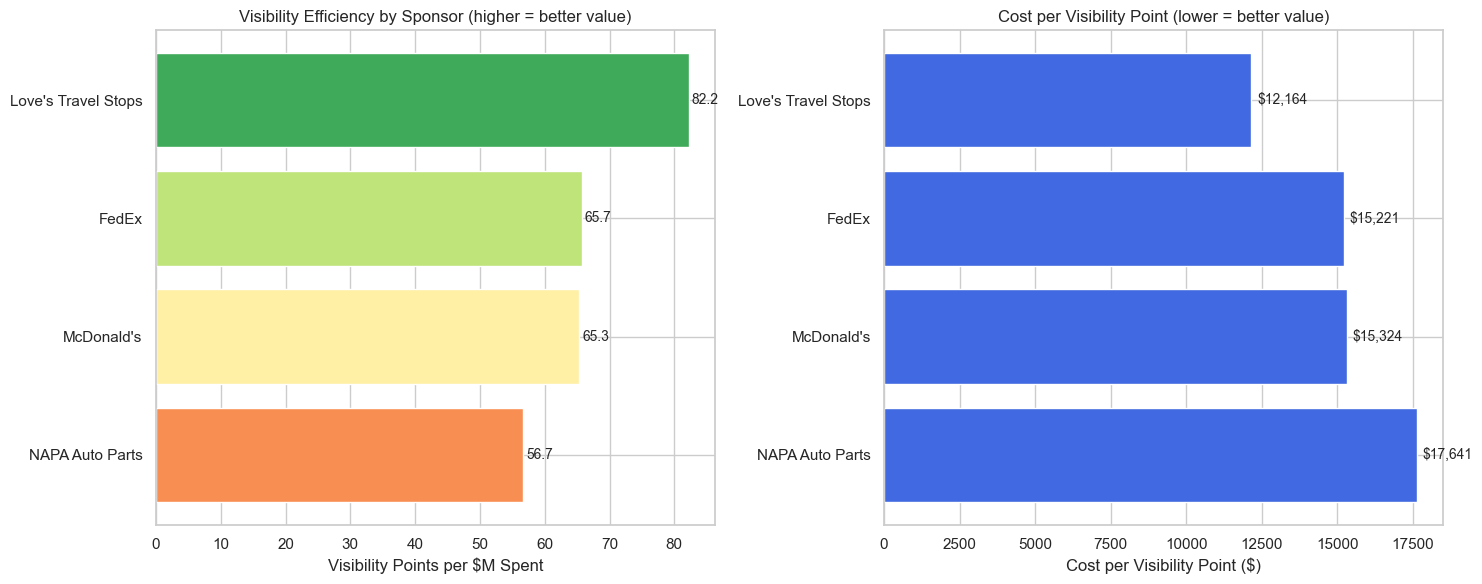

Saved efficiency_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
es = efficiency_df.sort_values('efficiency', ascending=True)
ax1 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(es)))
bars = ax1.barh(es['sponsor'], es['efficiency'], color=colors)
for b in bars:
    ax1.text(b.get_width() + 0.5, b.get_y() + b.get_height()/2, f'{b.get_width():.1f}', va='center', fontsize=10)
ax1.set_xlabel('Visibility Points per $M Spent')
ax1.set_title('Visibility Efficiency by Sponsor (higher = better value)')

ax2 = axes[1]
cs = efficiency_df.sort_values('cost_per_point', ascending=False)
bars2 = ax2.barh(cs['sponsor'], cs['cost_per_point'], color='#4169E1')
for b in bars2:
    ax2.text(b.get_width() + 200, b.get_y() + b.get_height()/2, f"${b.get_width():,.0f}", va='center', fontsize=10)
ax2.set_xlabel('Cost per Visibility Point ($)')
ax2.set_title('Cost per Visibility Point (lower = better value)')
plt.tight_layout()
plt.savefig(f'{OUT}/efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved efficiency_comparison.png')

### Visibility vs. Cost scatter (efficiency isolines)

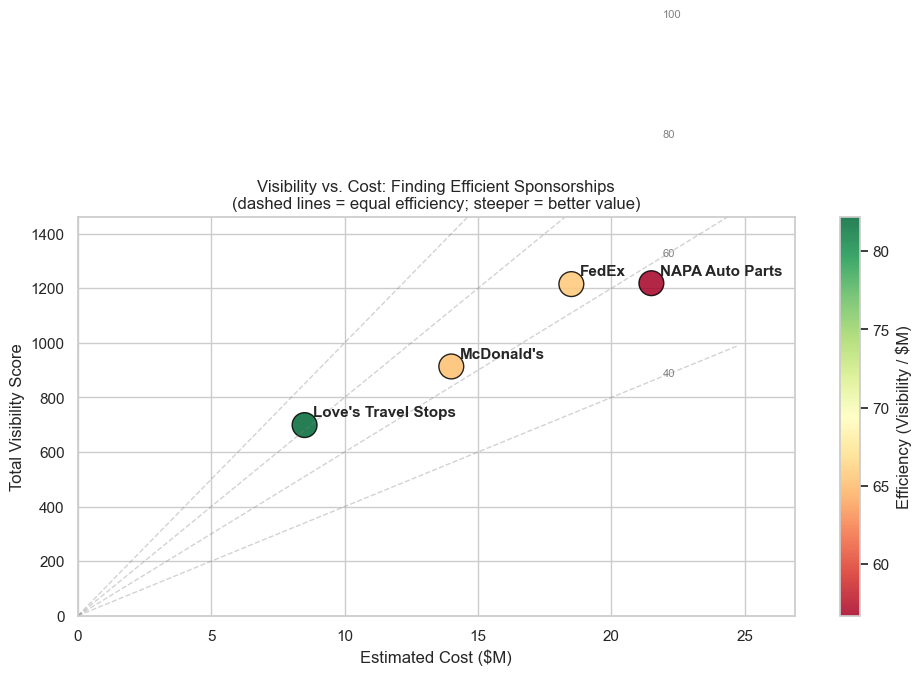

Saved visibility_cost_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(efficiency_df['cost_mid'], efficiency_df['total_visibility'], s=320,
                c=efficiency_df['efficiency'], cmap='RdYlGn', alpha=0.85, edgecolors='black', linewidth=1)
for _, row in efficiency_df.iterrows():
    ax.annotate(row['sponsor'], (row['cost_mid'], row['total_visibility']),
                xytext=(6, 6), textcoords='offset points', fontsize=11, fontweight='bold')
max_cost = efficiency_df['cost_mid'].max()
max_vis = efficiency_df['total_visibility'].max()
for eff in [40, 60, 80, 100]:
    x = np.linspace(0, max_cost * 1.15, 100)
    ax.plot(x, x * eff, '--', color='gray', alpha=0.35, linewidth=1)
    ax.text(max_cost * 1.02, max_cost * 1.02 * eff, f'{eff}', fontsize=8, color='gray')
ax.set_xlabel('Estimated Cost ($M)')
ax.set_ylabel('Total Visibility Score')
ax.set_title('Visibility vs. Cost: Finding Efficient Sponsorships\n(dashed lines = equal efficiency; steeper = better value)')
plt.colorbar(sc, ax=ax, label='Efficiency (Visibility / $M)')
ax.set_xlim(0, max_cost * 1.25)
ax.set_ylim(0, max_vis * 1.2)
plt.tight_layout()
plt.savefig(f'{OUT}/visibility_cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved visibility_cost_scatter.png')

## 5. Visibility Rank vs. Efficiency Rank

The most revealing comparison: sponsors that rise are better value per dollar; sponsors that
fall pay a premium (prestige, driver popularity, team brand equity).

In [9]:
comparison = efficiency_df[['sponsor','visibility_rank','efficiency_rank','total_visibility','cost_mid','efficiency']].copy()
comparison['rank_change'] = comparison['visibility_rank'] - comparison['efficiency_rank']
print('VISIBILITY RANK vs EFFICIENCY RANK')
print('=' * 70)
print(comparison.sort_values('efficiency_rank').round(1).to_string(index=False))
print()
for _, r in comparison.sort_values('efficiency_rank').iterrows():
    if r['rank_change'] > 0:
        print(f"  {r['sponsor']}: UP {int(r['rank_change'])} (better value per dollar than raw visibility suggests)")
    elif r['rank_change'] < 0:
        print(f"  {r['sponsor']}: DOWN {int(-r['rank_change'])} (pays a premium relative to visibility delivered)")
    else:
        print(f"  {r['sponsor']}: no change (consistent value across metrics)")

VISIBILITY RANK vs EFFICIENCY RANK
            sponsor  visibility_rank  efficiency_rank  total_visibility  cost_mid  efficiency  rank_change
Love's Travel Stops                4                1             698.8       8.5        82.2            3
              FedEx                2                2            1215.4      18.5        65.7            0
         McDonald's                3                3             913.6      14.0        65.3            0
    NAPA Auto Parts                1                4            1218.8      21.5        56.7           -3

  Love's Travel Stops: UP 3 (better value per dollar than raw visibility suggests)
  FedEx: no change (consistent value across metrics)
  McDonald's: no change (consistent value across metrics)
  NAPA Auto Parts: DOWN 3 (pays a premium relative to visibility delivered)


## 6. Cost Sensitivity (low / mid / high estimates)

Because costs are estimates, we re-rank efficiency using the low and high cost bounds and check
whether the efficiency ranking is stable.

In [10]:
def sensitivity_to_cost(df):
    out = df[['sponsor']].copy()
    for scen, col in [('low', 'cost_low'), ('mid', 'cost_mid'), ('high', 'cost_high')]:
        eff = df['total_visibility'] / df[col]
        out[f'eff_rank_{scen}'] = eff.rank(ascending=False).astype(int).values
    return out.set_index('sponsor')

cost_sensitivity = sensitivity_to_cost(efficiency_df)
print('Efficiency rank under different cost assumptions:')
print(cost_sensitivity)
cost_rank_range = (cost_sensitivity.max(axis=1) - cost_sensitivity.min(axis=1))
print('\nEfficiency-rank range by sponsor (0 = stable):')
print(cost_rank_range.sort_values().to_string())

Efficiency rank under different cost assumptions:
                     eff_rank_low  eff_rank_mid  eff_rank_high
sponsor                                                       
NAPA Auto Parts                 4             4              4
FedEx                           3             2              2
McDonald's                      2             3              3
Love's Travel Stops             1             1              1

Efficiency-rank range by sponsor (0 = stable):
sponsor
NAPA Auto Parts        0
Love's Travel Stops    0
FedEx                  1
McDonald's             1


## 7. Weight Sensitivity (four configurations)

Re-score visibility under alternative category weights and check whether the visibility ranking
is robust. Uses the normalized columns already in `scored_dataset.csv`.

In [11]:
scored_df = pd.read_csv(f'{OUT}/scored_dataset.csv')

WEIGHT_SCENARIOS = {
    'baseline':          {'name': 'Baseline (40/30/20/10)',        'race_performance':0.40,'media_coverage':0.30,'social_engagement':0.20,'special_events':0.10},
    'performance_heavy': {'name': 'Performance Heavy (50/25/15/10)','race_performance':0.50,'media_coverage':0.25,'social_engagement':0.15,'special_events':0.10},
    'media_heavy':       {'name': 'Media Heavy (30/40/20/10)',     'race_performance':0.30,'media_coverage':0.40,'social_engagement':0.20,'special_events':0.10},
    'equal_weights':     {'name': 'Equal Weights (25/25/25/25)',   'race_performance':0.25,'media_coverage':0.25,'social_engagement':0.25,'special_events':0.25},
}

WITHIN = {
    'race_performance': [('finish_norm',0.70),('laps_led_norm',0.30)],
    'media_coverage':   [('news_norm',1.00)],
    'social_engagement':[('reddit_norm',0.50),('youtube_norm',0.50)],
    'special_events':   [('win_norm',0.60),('playoff_norm',0.40)],
}

def calculate_score_with_weights(row, category_weights):
    score = 0.0
    for cat, cw in category_weights.items():
        if cat == 'name':
            continue
        for norm_col, within_w in WITHIN.get(cat, []):
            score += row[norm_col] * cw * within_w
    return score

def run_scenario(df, name, weights):
    d = df.copy()
    d['score'] = d.apply(lambda r: calculate_score_with_weights(r, weights), axis=1)
    season = d.groupby('sponsor').agg(**{f'total_{name}': ('score', 'sum')})
    season[f'rank_{name}'] = season[f'total_{name}'].rank(ascending=False).astype(int)
    return season

scenario_results = {n: run_scenario(scored_df, n, w) for n, w in WEIGHT_SCENARIOS.items()}
sensitivity_df = pd.concat(scenario_results.values(), axis=1)
rank_cols = [c for c in sensitivity_df.columns if c.startswith('rank_')]
print('RANKING ACROSS WEIGHT SCENARIOS')
print('=' * 70)
print(sensitivity_df[rank_cols])

stability = pd.DataFrame(index=sensitivity_df.index)
stability['min_rank'] = sensitivity_df[rank_cols].min(axis=1)
stability['max_rank'] = sensitivity_df[rank_cols].max(axis=1)
stability['rank_range'] = stability['max_rank'] - stability['min_rank']
print('\nRank stability (rank_range 0 = perfectly stable):')
print(stability.sort_values('rank_range').to_string())

max_range = int(stability['rank_range'].max())
verdict = ('ROBUST' if max_range <= 1 else 'MOSTLY ROBUST' if max_range <= 2 else 'SENSITIVE')
print(f'\nOverall robustness: {verdict} (max rank range = {max_range})')

RANKING ACROSS WEIGHT SCENARIOS
                     rank_baseline  rank_performance_heavy  rank_media_heavy  \
sponsor                                                                        
FedEx                            2                       2                 1   
Love's Travel Stops              4                       4                 4   
McDonald's                       3                       3                 3   
NAPA Auto Parts                  1                       1                 2   

                     rank_equal_weights  
sponsor                                  
FedEx                                 1  
Love's Travel Stops                   4  
McDonald's                            3  
NAPA Auto Parts                       2  

Rank stability (rank_range 0 = perfectly stable):
                     min_rank  max_rank  rank_range
sponsor                                            
Love's Travel Stops         4         4           0
McDonald's                  

### Weight-impact and sensitivity visualization

WEIGHT IMPACT (vs baseline)
         scenario  total_rank_changes  max_rank_change  sponsors_affected
performance_heavy                   0                0                  0
      media_heavy                   2                1                  2
    equal_weights                   2                1                  2


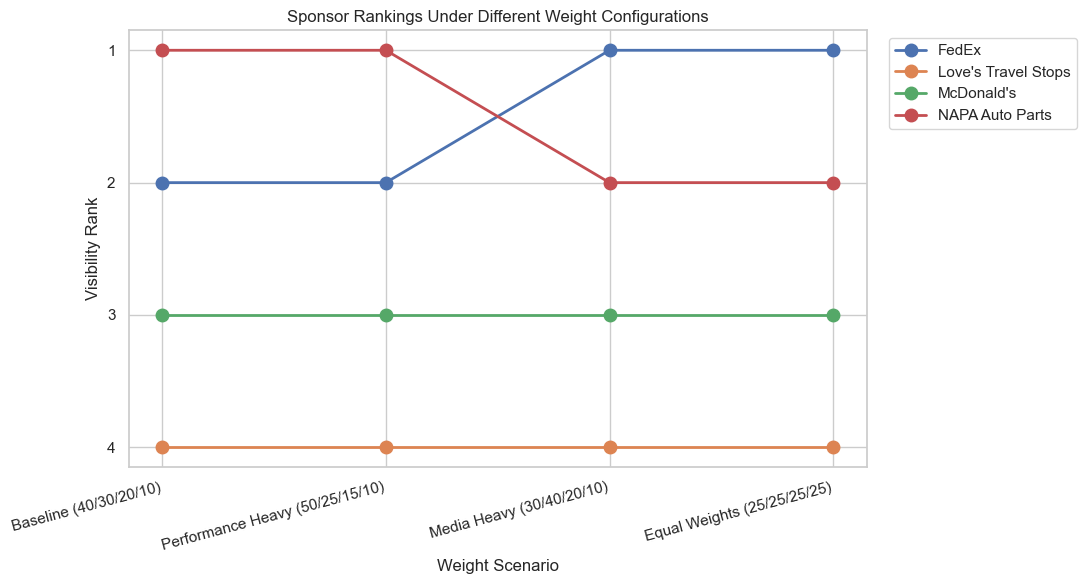

Saved sensitivity_analysis.png


In [12]:
baseline_ranks = scenario_results['baseline']['rank_baseline']
impacts = []
for scen in ['performance_heavy', 'media_heavy', 'equal_weights']:
    alt = scenario_results[scen][f'rank_{scen}']
    changes = (alt - baseline_ranks).abs()
    impacts.append({'scenario': scen, 'total_rank_changes': int(changes.sum()),
                    'max_rank_change': int(changes.max()), 'sponsors_affected': int((changes > 0).sum())})
weight_impact = pd.DataFrame(impacts)
print('WEIGHT IMPACT (vs baseline)')
print(weight_impact.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
scenarios = list(WEIGHT_SCENARIOS.keys())
for sponsor in sensitivity_df.index:
    ranks = [sensitivity_df.loc[sponsor, f'rank_{s}'] for s in scenarios]
    ax.plot([WEIGHT_SCENARIOS[s]['name'] for s in scenarios], ranks, marker='o', markersize=9, linewidth=2, label=sponsor)
ax.set_ylabel('Visibility Rank'); ax.set_xlabel('Weight Scenario')
ax.set_title('Sponsor Rankings Under Different Weight Configurations')
ax.set_yticks(range(1, len(sensitivity_df) + 1))
ax.invert_yaxis()
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT}/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sensitivity_analysis.png')

## 8. Save Rankings and Documents

In [13]:
# efficiency_rankings.csv
efficiency_export = efficiency_df[['sponsor','total_visibility','visibility_rank','cost_mid',
    'efficiency','cost_per_point','efficiency_rank','confidence']].sort_values('efficiency_rank')
efficiency_export.to_csv(f'{OUT}/efficiency_rankings.csv', index=False)

# rankings.csv (combined visibility + efficiency + stability)
final_rankings = efficiency_df[['sponsor','total_visibility','visibility_rank','cost_mid','efficiency','efficiency_rank']].copy()
final_rankings = final_rankings.merge(stability[['rank_range']].reset_index(), on='sponsor')
final_rankings = final_rankings.rename(columns={'rank_range': 'weight_rank_range'}).sort_values('visibility_rank')
final_rankings.to_csv(f'{OUT}/rankings.csv', index=False)
print('Saved efficiency_rankings.csv and rankings.csv')
print(final_rankings.round(1).to_string(index=False))

Saved efficiency_rankings.csv and rankings.csv
            sponsor  total_visibility  visibility_rank  cost_mid  efficiency  efficiency_rank  weight_rank_range
    NAPA Auto Parts            1218.8                1      21.5        56.7                4                  1
              FedEx            1215.4                2      18.5        65.7                2                  1
         McDonald's             913.6                3      14.0        65.3                3                  0
Love's Travel Stops             698.8                4       8.5        82.2                1                  0


### Sensitivity analysis document

In [14]:
lines = ['# Sensitivity Analysis Results', '',
         f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}", '',
         '## Weight Scenarios Tested', '',
         '| Scenario | Performance | Media | Social | Events |',
         '|---|:---:|:---:|:---:|:---:|',
         '| Baseline | 40% | 30% | 20% | 10% |',
         '| Performance Heavy | 50% | 25% | 15% | 10% |',
         '| Media Heavy | 30% | 40% | 20% | 10% |',
         '| Equal Weights | 25% | 25% | 25% | 25% |', '',
         '## Rank Stability (weight scenarios)', '',
         '| Sponsor | Min Rank | Max Rank | Range |', '|---|:---:|:---:|:---:|']
for sp, r in stability.sort_values('rank_range').iterrows():
    lines.append(f"| {sp} | {int(r['min_rank'])} | {int(r['max_rank'])} | {int(r['rank_range'])} |")
lines += ['', '## Weight Impact (vs baseline)', '',
          '| Scenario | Total rank changes | Max change | Sponsors affected |', '|---|:---:|:---:|:---:|']
for _, r in weight_impact.iterrows():
    lines.append(f"| {r['scenario']} | {r['total_rank_changes']} | {r['max_rank_change']} | {r['sponsors_affected']} |")
lines += ['', '## Cost Sensitivity (efficiency rank under low/mid/high cost)', '',
          '| Sponsor | Low | Mid | High | Range |', '|---|:---:|:---:|:---:|:---:|']
for sp in cost_sensitivity.index:
    row = cost_sensitivity.loc[sp]
    lines.append(f"| {sp} | {int(row['eff_rank_low'])} | {int(row['eff_rank_mid'])} | {int(row['eff_rank_high'])} | {int(cost_rank_range[sp])} |")
lines += ['', '## Conclusion', '']
if max_range <= 1:
    lines.append('**Model is ROBUST.** Visibility rankings are stable across weight configurations '
                 '(each sponsor moves at most one position). Core conclusions do not depend on the exact weights.')
elif max_range <= 2:
    lines.append('**Model is MOSTLY ROBUST.** Rankings show minor variation (1-2 positions) under different weights. '
                 'Conclusions about the top and bottom performers hold.')
else:
    lines.append('**Model is SENSITIVE.** Rankings shift materially under different weights; present multiple scenarios.')
lines += ['', '## Recommendations', '',
          '1. Use baseline weights (40/30/20/10) for primary analysis.',
          '2. Report the sensitivity findings alongside the rankings for transparency.',
          '3. Where visibility ranks are close (e.g. the top two sponsors), note that ordering can flip under reasonable weight changes.']
with open(f'{OUT}/sensitivity_analysis.md', 'w') as f:
    f.write('\n'.join(lines))
print('Saved sensitivity_analysis.md')

Saved sensitivity_analysis.md


### Methodology document (primary deliverable)

In [15]:
cfg = json.load(open(f'{OUT}/scoring_config.json'))
vis = efficiency_df.sort_values('visibility_rank')
eff = efficiency_df.sort_values('efficiency_rank')

m = []
m.append('# NASCAR Sponsorship Visibility Scoring Model - Methodology')
m.append('')
m.append(f"**Version:** 1.0  **Date:** {pd.Timestamp.now().strftime('%Y-%m-%d')}  **Analyst:** Aylin Yasgul")
m.append('')
m.append('## Executive Summary')
m.append('')
m.append('This document describes the methodology used to score, rank, and evaluate the ROI efficiency '
         'of NASCAR Cup Series sponsors for the 2024 season. The model combines race performance, media '
         'coverage, and social engagement into a composite 0-100 visibility score, aggregates it to a '
         'season total, and divides by estimated sponsorship cost to measure value per dollar.')
m.append('')
m.append('## 1. Variables and Weights')
m.append('')
m.append('| Category | Variable | Description | Effective Weight |')
m.append('|---|---|---|:---:|')
desc = {'finish_position':'Race finishing position (inverted)','laps_led':'Number of laps leading',
        'news_weighted_mentions':'Quality-weighted news articles','reddit_mentions':'r/NASCAR mentions (Google Trends proxy)',
        'youtube_sponsor_views':'Views on sponsor-related videos','is_win':'Binary flag for race wins','is_playoff':'Binary flag for playoff races'}
catname = {'race_performance':'Race Performance','media_coverage':'Media Coverage','social_engagement':'Social Engagement','special_events':'Special Events'}
for v, meta in cfg['variables'].items():
    m.append(f"| {catname[meta['category']]} | {v} | {desc[v]} | {meta['effective_weight']*100:.0f}% |")
m.append('| **TOTAL** | | | **100%** |')
m.append('')
m.append('**Weight rationale:** category weights (Race Performance 40%, Media 30%, Social 20%, Special '
         'Events 10%) come from industry sponsorship-ROI frameworks, refined by the Project 3 EDA. News '
         'carries the highest single weight (30%) because it was the only exposure channel that varied '
         'cleanly by sponsor and produced a statistically significant performance link (Laps Led to News, '
         'r = +0.181, p = 0.030).')
m.append('')
m.append('## 2. Data Sources')
m.append('')
m.append('| Source | Data | Collection |')
m.append('|---|---|---|')
m.append('| Racing Reference / Kaggle | Finish position, laps led | API / download |')
m.append('| Reddit via Google Trends proxy | Social interest (r/NASCAR) | Trends API (Reddit API returned 403) |')
m.append('| YouTube Data API | Sponsor video views | API |')
m.append('| Manual news tracking | Weighted news mentions | Search + tiered weighting |')
m.append('| Industry benchmarks (Forbes, SBJ) | Sponsorship cost estimates | Tier-based estimates |')
m.append('')
m.append('## 3. Scoring Methodology')
m.append('')
m.append('- **Normalization:** min-max to 0-100. `normalized = (value - min) / (max - min) * 100`, season-wide.')
m.append('- **Special cases:** finish position inverted (P1 = 100); YouTube views log-transformed before '
         'normalizing; binary flags scaled to 0/100.')
m.append('- **Weekly score:** `SUM(normalized_value * effective_weight)`.')
m.append('- **Season total:** `SUM(weekly_scores)` (sum, not average, because all sponsors ran all 36 races).')
m.append('- **Efficiency:** `total_visibility / estimated_cost_in_millions` (points per $M).')
m.append('')
m.append('## 4. Assumptions and Limitations')
m.append('')
m.append('1. Cost estimates are approximations - exact sponsorship values are confidential.')
m.append('2. Reddit is a Google Trends proxy and, like total YouTube views, is race-level (identical across '
         'sponsors within a race), so it does not differentiate sponsors in the ranking.')
m.append('3. youtube_sponsor_views is non-zero in only 4 of 144 rows, so its weight contributes little in practice.')
m.append('4. Sponsorship packages differ (primary vs associate assets), so cost-per-visibility compares unlike packages.')
m.append('5. Efficiency values are on this model internal 0-100 score scale, so absolute numbers are not directly '
         'comparable to external industry benchmarks; the relative ranking is what matters.')
m.append('6. Intangibles (prestige, B2B/hospitality value, strategic fit) are not captured by efficiency.')
m.append('')
m.append('## 5. Sensitivity Analysis')
m.append('')
m.append(f"- **Weight sensitivity:** tested 4 configurations (baseline, performance-heavy, media-heavy, equal). "
         f"Maximum rank movement was {max_range} position(s): the model is {verdict.lower()}.")
m.append('- **Cost sensitivity:** efficiency ranks were re-computed under low/mid/high cost estimates '
         f"(max efficiency-rank movement {int(cost_rank_range.max())} position(s)).")
m.append('')
m.append('## 6. Results Summary')
m.append('')
m.append('### 6.1 Visibility Rankings')
m.append('')
m.append('| Rank | Sponsor | Total Visibility | Est. Cost |')
m.append('|:---:|---|:---:|:---:|')
for _, r in vis.iterrows():
    m.append(f"| {int(r['visibility_rank'])} | {r['sponsor']} | {r['total_visibility']:.0f} | ${r['cost_mid']:.1f}M |")
m.append('')
m.append('### 6.2 Efficiency Rankings (value per dollar)')
m.append('')
m.append('| Rank | Sponsor | Visibility/$M | Cost per Point | Value note |')
m.append('|:---:|---|:---:|:---:|---|')
for _, r in eff.iterrows():
    change = int(r['visibility_rank'] - r['efficiency_rank'])
    note = 'best value per dollar' if r['efficiency_rank'] == 1 else ('premium for prestige/performance' if change < 0 else ('better value than visibility suggests' if change > 0 else 'consistent value'))
    m.append(f"| {int(r['efficiency_rank'])} | {r['sponsor']} | {r['efficiency']:.1f} | ${r['cost_per_point']:,.0f} | {note} |")
m.append('')
m.append('## 7. Appendix - Files Generated')
m.append('')
m.append('| File | Description |')
m.append('|---|---|')
for fn, d in [('rankings.csv','Final visibility and efficiency rankings'),
              ('efficiency_rankings.csv','Detailed efficiency analysis'),
              ('scored_dataset.csv','Full dataset with visibility scores'),
              ('cost_estimates.csv','Sponsorship cost research'),
              ('sensitivity_analysis.md','Weight and cost sensitivity results'),
              ('validation_report.md','Model validation results (Module 4.2)'),
              ('methodology.md','This document')]:
    m.append(f"| `{fn}` | {d} |")
m.append('')
m.append('All analysis code is in `code/` (scoring_methodology, visibility_scoring_model, roi_efficiency_analysis).')
m.append('')
m.append('*This methodology document supports the NASCAR Sponsorship ROI analysis for NY Racing.*')

with open(f'{OUT}/methodology.md', 'w') as f:
    f.write('\n'.join(m))
print('Saved methodology.md')

Saved methodology.md
